# Feature Hierarchies and Representations

In [ ]:
!pip install -q umap-learn

In [ ]:
import types
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
import torchvision

from torch.utils.data import DataLoader, Subset
from sklearn.manifold import TSNE
import umap.umap_ as umap

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [ ]:
data_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=data_transform
)

class_names = test_dataset.classes

print(class_names)
print("Test samples:", len(test_dataset))

100%|██████████| 170M/170M [20:39<00:00, 138kB/s]


['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Test samples: 10000


In [ ]:
samples_per_class = 100

targets = np.array(test_dataset.targets)
indices = []

for class_idx in range(10):
    class_indices = np.where(targets == class_idx)[0]
    indices.extend(class_indices[:samples_per_class])

subset = Subset(test_dataset, indices)

loader = DataLoader(
    subset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Samples:", len(subset))

Samples: 1000


In [ ]:
def create_resnet152():
    model = models.resnet152(
        weights='IMAGENET1K_V2'
    )

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.fc.in_features

    model.fc = nn.Linear(
        num_ftrs,
        len(class_names)
    )

    return model

In [ ]:
model_skip = create_resnet152()

model_skip.load_state_dict(
    torch.load(
        "resnet152_cifar10_head.pt",
        map_location=device
    )
)

model_skip = model_skip.to(device)
model_skip.eval()

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
def make_no_skip_forward(block):
    def forward(self, x):

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        # Skip connection intentionally removed
        out = self.relu(out)

        return out

    return forward

In [ ]:
def disable_skip_connections(model, block_specs):

    for layer_name, block_idx in block_specs:

        layer = getattr(model, layer_name)
        block = layer[block_idx]

        block.forward = types.MethodType(
            make_no_skip_forward(block),
            block
        )

    return model

In [ ]:
model_noskip = create_resnet152()

block_specs = [
    ('layer1', 1),
    ('layer2', 4),
    ('layer3', 18),
    ('layer4', 1),
]

model_noskip = disable_skip_connections(
    model_noskip,
    block_specs
)

model_noskip.load_state_dict(
    torch.load(
        "resnet152_cifar10_noskip_head.pt",
        map_location=device
    )
)

model_noskip = model_noskip.to(device)
model_noskip.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
def extract_features(model, loader):

    features = {
        "early": [],
        "middle": [],
        "late": []
    }

    labels = []

    activations = {}

    def make_hook(name):

        def hook(module, input, output):
            activations[name] = output.detach()

        return hook

    hooks = [
        model.layer1.register_forward_hook(
            make_hook("early")
        ),

        model.layer3.register_forward_hook(
            make_hook("middle")
        ),

        model.layer4.register_forward_hook(
            make_hook("late")
        )
    ]

    model.eval()

    with torch.no_grad():

        for images, batch_labels in loader:

            images = images.to(device)

            # Forward pass triggers all hooks
            model(images)

            for name in features:

                x = activations[name]

                # Global Average Pooling
                x = x.mean(
                    dim=(2, 3)
                )

                features[name].append(
                    x.cpu().numpy()
                )

            labels.extend(
                batch_labels.numpy()
            )

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # Concatenate batches
    for name in features:

        features[name] = np.concatenate(
            features[name],
            axis=0
        )

    labels = np.array(labels)

    return features, labels

In [ ]:
features_skip, labels = extract_features(
    model_skip,
    loader
)

features_noskip, labels_noskip = extract_features(
    model_noskip,
    loader
)

In [ ]:
for name in features_skip:

    print(
        f"{name:>6}:",
        features_skip[name].shape
    )

 early: (1000, 256)
middle: (1000, 1024)
  late: (1000, 2048)


In [ ]:
def run_tsne(features):

    reducer = TSNE(
        n_components=2,
        perplexity=30,
        init="pca",
        learning_rate="auto",
        random_state=42
    )

    return reducer.fit_transform(features)

In [ ]:
tsne_skip = {}

for layer, features in features_skip.items():

    print("t-SNE:", layer)

    tsne_skip[layer] = run_tsne(
        features
    )

t-SNE: early
t-SNE: middle
t-SNE: late


In [ ]:
tsne_noskip = {}

for layer, features in features_noskip.items():

    print("t-SNE:", layer)

    tsne_noskip[layer] = run_tsne(
        features
    )

t-SNE: early
t-SNE: middle
t-SNE: late


In [ ]:
def run_umap(features):

    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        random_state=42
    )

    return reducer.fit_transform(features)

In [ ]:
umap_skip = {}

for layer, features in features_skip.items():

    print("UMAP:", layer)

    umap_skip[layer] = run_umap(
        features
    )

UMAP: early


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: middle


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: late


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
umap_noskip = {}

for layer, features in features_noskip.items():

    print("UMAP:", layer)

    umap_noskip[layer] = run_umap(
        features
    )

UMAP: early


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: middle


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: late


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
def plot_embeddings(
    embeddings,
    labels,
    method,
    model_name
):

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    layers = [
        "early",
        "middle",
        "late"
    ]

    for ax, layer in zip(
        axes,
        layers
    ):

        points = embeddings[layer]

        scatter = ax.scatter(
            points[:, 0],
            points[:, 1],
            c=labels,
            cmap="tab10",
            s=15,
            alpha=0.7
        )

        ax.set_title(
            f"{model_name}\n"
            f"{layer.capitalize()} — {method}"
        )

        ax.set_xlabel(
            "Component 1"
        )

        ax.set_ylabel(
            "Component 2"
        )

    plt.tight_layout()
    plt.show()

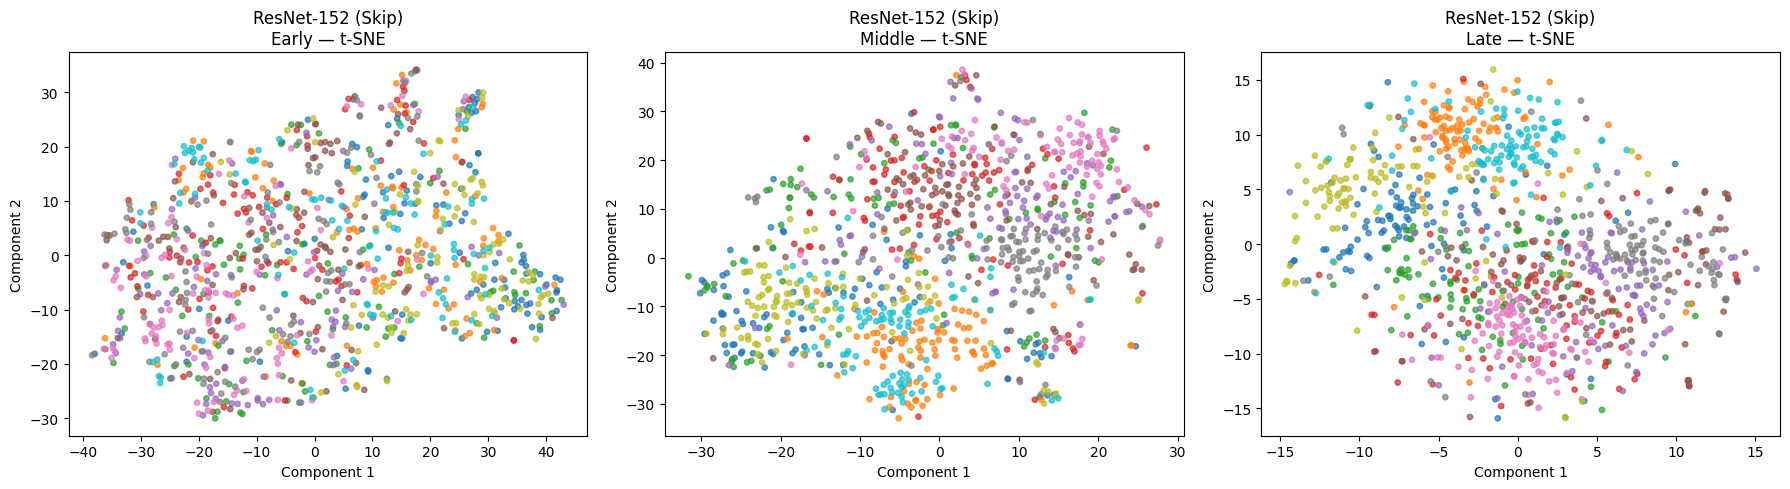

In [ ]:
plot_embeddings(
    tsne_skip,
    labels,
    "t-SNE",
    "ResNet-152 (Skip)"
)

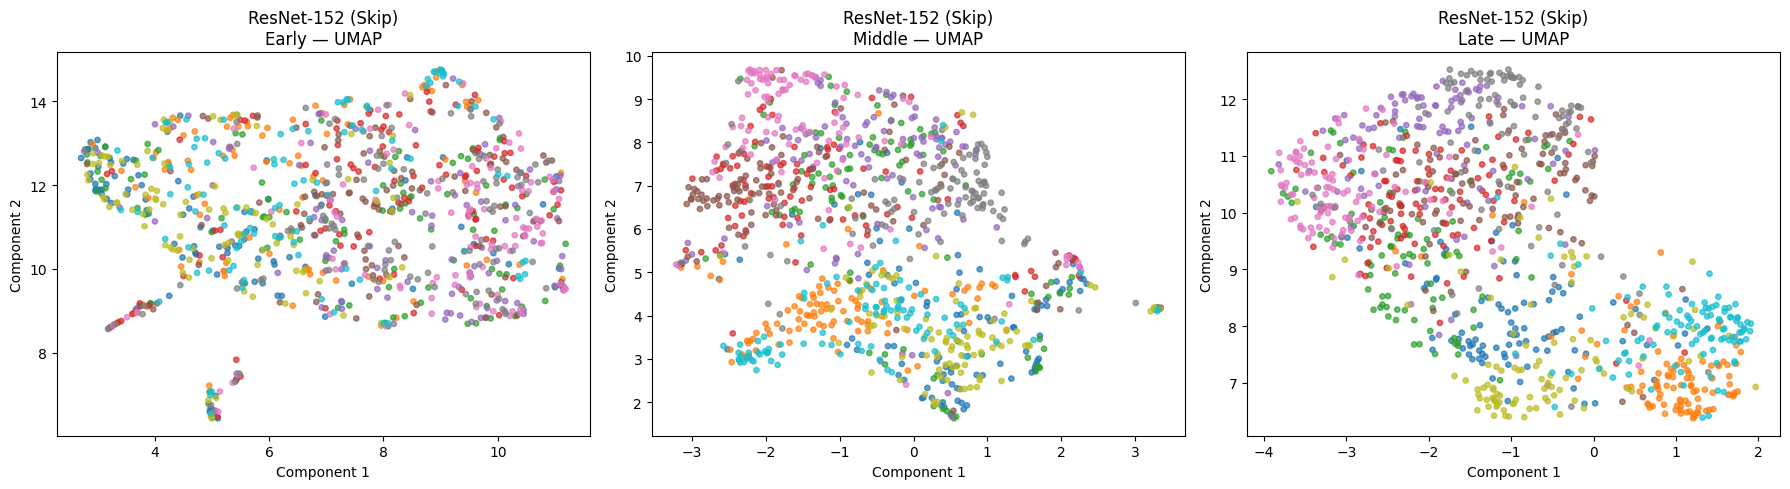

In [ ]:
plot_embeddings(
    umap_skip,
    labels,
    "UMAP",
    "ResNet-152 (Skip)"
)

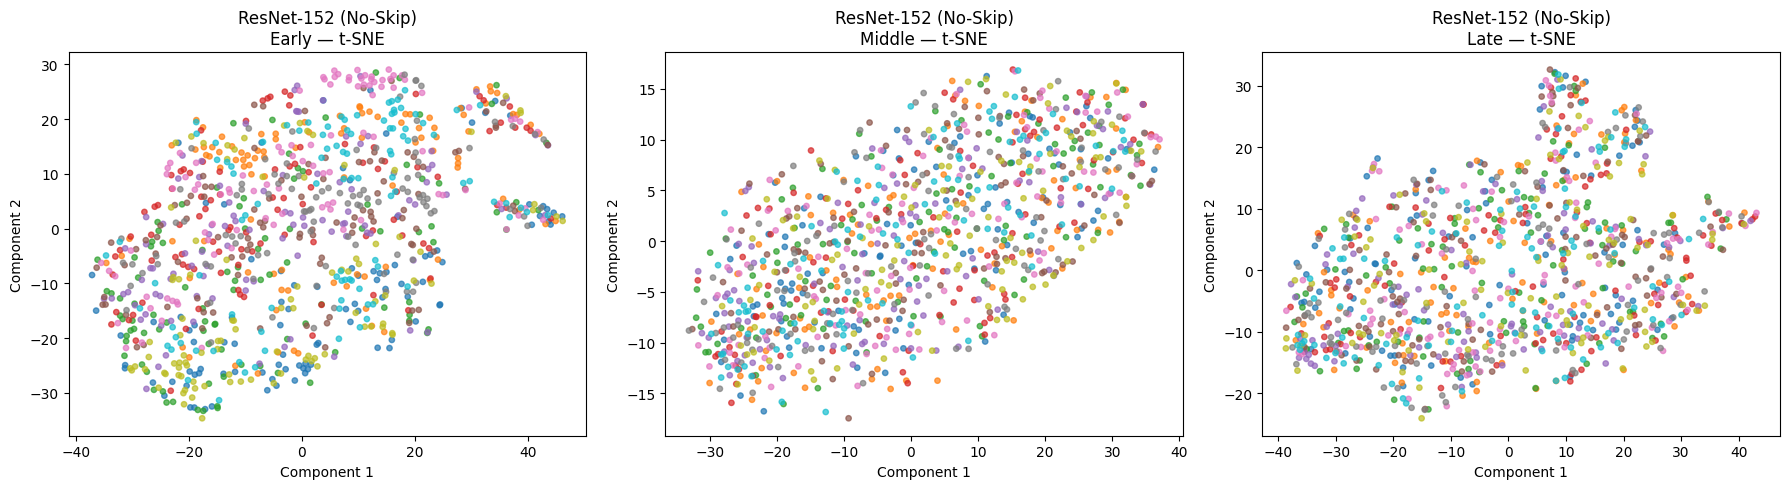

In [ ]:
plot_embeddings(
    tsne_noskip,
    labels_noskip,
    "t-SNE",
    "ResNet-152 (No-Skip)"
)

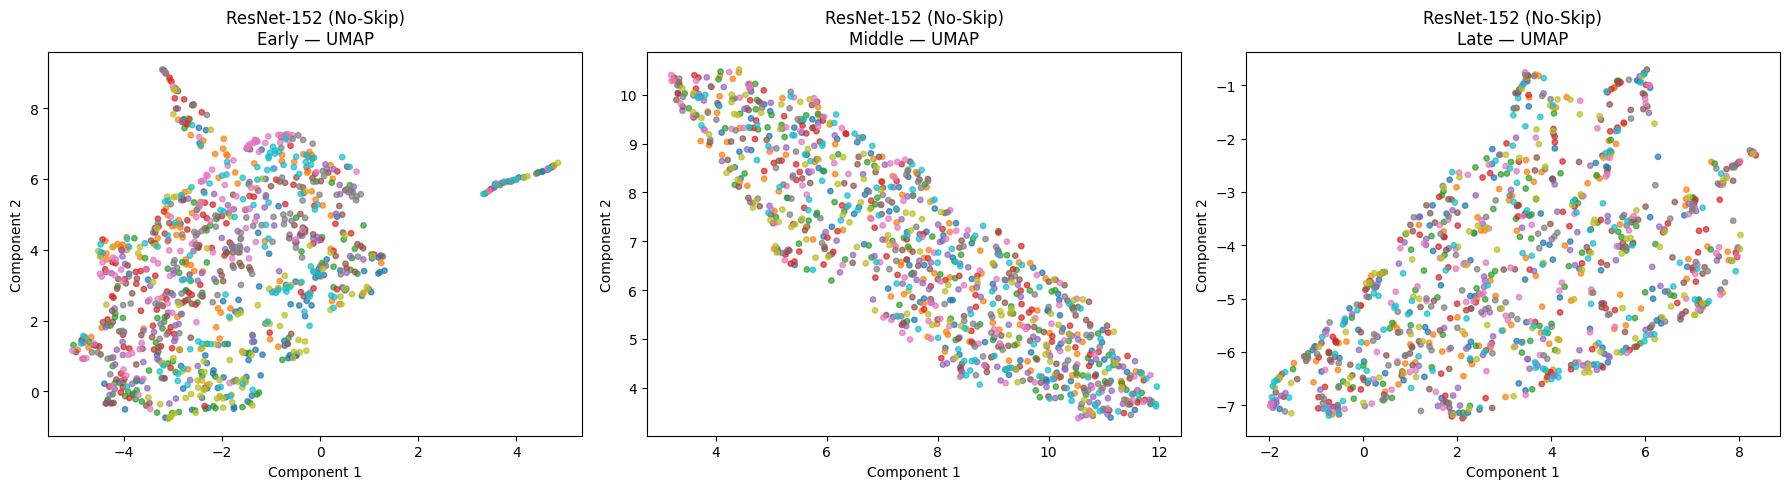

In [ ]:
plot_embeddings(
    umap_noskip,
    labels_noskip,
    "UMAP",
    "ResNet-152 (No-Skip)"
)